# How to run Bayesian LM specification tests

You have a spatial dataset and need to decide which model to fit: is the
dependence in the outcome (a lag), in the errors, in the neighbours'
covariates, or some combination? The Lagrange-Multiplier tests answer that
before you commit to a specification.

`neighbayes` evaluates each LM statistic at every posterior draw, so you get a
posterior distribution of the statistic rather than a single point. The full
inventory of tests, their null hypotheses and degrees of freedom, and the
Neyman-orthogonal construction behind the robust variants are in
[Supported Models](../models.md).

In [1]:
import warnings

import libpysal
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neighbayes.diagnostics.lmtests import (
    bayesian_lm_error_sdm_test,
    bayesian_lm_error_test,
    bayesian_lm_lag_sdem_test,
    bayesian_lm_lag_test,
    bayesian_lm_sdm_joint_test,
    bayesian_lm_slx_error_joint_test,
    bayesian_lm_wx_sem_test,
    bayesian_lm_wx_test,
    bayesian_robust_lm_error_sdem_test,
    bayesian_robust_lm_error_test,
    bayesian_robust_lm_lag_sdm_test,
    bayesian_robust_lm_lag_test,
    bayesian_robust_lm_wx_test,
)
from neighbayes.models import OLS, SAR, SDEM, SDM, SEM, SLX

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Set up data and weights

We create a simple spatial DGP with known parameters to validate the tests. Under the null hypothesis (no spatial effects), the Bayesian LM statistics should be small with high p-values.

In [2]:
import geopandas as gpd
from libpysal.graph import Graph
from libpysal.weights import Rook

# Generate data under H0: no spatial effects
np.random.seed(42)

# Load Columbus dataset for spatial weights
columbus_path = libpysal.examples.get_path("columbus.shp")
gdf = gpd.read_file(columbus_path)

# Create a Graph (modern libpysal API) for neighbayes models
# Row-standardize the graph so spatial models work correctly
g = Graph.build_contiguity(gdf, rook=True).transform("r")
n = g.n

# Legacy W for spreg comparison
w_spreg = Rook.from_shapefile(columbus_path)
w_spreg.transform = "r"

# Get sparse and dense W matrices
W_sparse = g.sparse.tocsr().astype(np.float64)
W_dense = np.array(W_sparse.todense())

# Design matrix
k = 3
X = np.column_stack([np.ones(n), np.random.normal(size=(n, k - 1))])
beta_true = np.array([1.0, 2.0, -1.5])
y = X @ beta_true + np.random.normal(scale=1.0, size=n)

print(f"W shape: {W_sparse.shape}, nnz: {W_sparse.nnz}")

W shape: (49, 49), nnz: 200


## Fit the null models the tests need

The Bayesian LM tests require posterior draws from the **null model** (the model under H₀). Different tests use different null models:

- **LM-WX test**: SAR model (includes ρ but not γ)
- **LM-SDM joint test**: OLS model (no spatial params)
- **LM-SLX-Error joint test**: OLS model (no spatial params)
- **Robust LM-Lag-SDM**: SLX model (includes γ but not ρ)
- **Robust LM-WX**: SAR model (includes ρ but not γ)
- **Robust LM-Error-SDEM**: SLX model (includes γ but not λ)

In [3]:
# Fit OLS model (null for joint tests)
ols_model = OLS(y=y, X=X, W=g)
ols_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)

# Fit SAR model (null for LM-WX and robust LM-WX)
sar_model = SAR(y=y, X=X, W=g)
sar_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)

# Fit SLX model (null for robust LM-Lag-SDM and robust LM-Error-SDEM)
slx_model = SLX(y=y, X=X, W=g)
slx_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma2]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.


Gibbs sampling (sar): 4 chains for 5,000 tune and 5,000 draw iterations (4 x 10,000 = 40,000 draws total)

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma2]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

## Test for a lag, an error, or lagged covariates

These tests assume the nuisance parameters are correctly specified (zero). They are the Bayesian analogues of the classical LM tests from Koley & Bera (2024).

In [4]:
# Fit the SEM null required by LM-WX-SEM (Bayesian analogue of Koley–Bera 2024).
sem_model = SEM(y=y, X=X, W=g)
sem_model.fit(draws=2500, tune=2500, chains=2, random_seed=42)

# Non-robust Bayesian LM tests evaluated at the appropriate null model.
non_robust_results = pd.DataFrame(
    [
        bayesian_lm_lag_test(ols_model).to_series(),
        bayesian_lm_error_test(ols_model).to_series(),
        bayesian_lm_wx_test(sar_model).to_series(),
        bayesian_lm_wx_sem_test(sem_model).to_series(),
        bayesian_lm_sdm_joint_test(ols_model).to_series(),
        bayesian_lm_slx_error_joint_test(ols_model).to_series(),
    ],
    index=[
        "LM-Lag",
        "LM-Error",
        "LM-WX",
        "LM-WX-SEM",
        "LM-SDM Joint",
        "LM-SLX-Error Joint",
    ],
)

non_robust_results

Gibbs sampling (sem): 2 chains for 2,500 tune and 2,500 draw iterations (2 x 5,000 = 10,000 draws total)

Output()

,lm_samples,mean,median,credible_interval,bayes_pvalue,test_type,df,n_draws,k_wx
LM-Lag,"[0.21429649997143094, 1.0784033337487549, 1.28...",1.063234,0.656830,"(0.0020467568217568738, 4.268767796903476)",0.302479,bayesian_lm_lag,1,20000,NaN
LM-Error,"[0.7079187163674537, 0.7756572487282556, 0.744...",0.669052,0.683859,"(0.014393878917329142, 1.38539118454434)",0.413382,bayesian_lm_error,1,20000,NaN
LM-WX,"[1.4814399069845419, 3.3609870142814255, 0.880...",2.112357,1.413838,"(0.09593622926595671, 8.194730280544018)",0.347782,bayesian_lm_wx,2,20000,2.0
LM-WX-SEM,"[3.2315485732635767, 1.0743489513363145, 0.196...",1.351305,0.898337,"(0.05536302605253851, 5.110249054287488)",0.508824,bayesian_lm_wx_sem,2,5000,2.0
LM-SDM Joint,"[0.7240693263411901, 2.7662057621910168, 2.499...",3.926935,2.786218,"(0.425523102567828, 14.128384100207581)",0.269463,bayesian_lm_sdm_joint,3,20000,2.0
LM-SLX-Error Joint,"[1.3998088300832803, 3.503434583833459, 1.5975...",2.113251,1.633809,"(0.7011929236378864, 6.14925226708313)",0.549237,bayesian_lm_slx_error_joint,3,20000,2.0


## Use the robust variants when both channels may be present

These tests use the **Neyman orthogonal score adjustment** from Dogan et al. (2021, Proposition 3) to ensure robustness against local misspecification in the nuisance parameter. This is the key innovation over the classical Bera-Yoon (1993) approach.

The adjustment removes the correlation between the test parameter score and the nuisance parameter score:

$$g_\psi^* = g_\psi - J_{\psi\phi \cdot \sigma} \, J_{\phi\phi \cdot \sigma}^{-1} \, g_\phi$$

where $J_{\cdot \cdot \cdot \sigma}$ denotes information matrix blocks partitioned on $\sigma^2$.

In [5]:
# Robust Bayesian LM tests (Neyman orthogonal score)
robust_results = pd.DataFrame(
    [
        bayesian_robust_lm_lag_test(ols_model).to_series(),
        bayesian_robust_lm_error_test(ols_model).to_series(),
        bayesian_robust_lm_lag_sdm_test(slx_model).to_series(),
        bayesian_robust_lm_wx_test(sar_model).to_series(),
        bayesian_robust_lm_error_sdem_test(slx_model).to_series(),
    ],
    index=[
        "Robust LM-Lag",
        "Robust LM-Error",
        "Robust LM-Lag-SDM",
        "Robust LM-WX",
        "Robust LM-Error-SDEM",
    ],
)

robust_results

,lm_samples,mean,median,credible_interval,bayes_pvalue,test_type,df,n_draws,k_wx,tr_MzWMzW_pair
Robust LM-Lag,"[0.04470652999465252, 0.0603932100163469, 0.04...",0.052556,0.049121,"(0.021080445691699236, 0.10259303831611918)",0.818673,bayesian_robust_lm_lag,1,20000,NaN,NaN
Robust LM-Error,"[0.25920888331861286, 0.350160402299982, 0.236...",0.304723,0.284806,"(0.12222462329904865, 0.5948354055071102)",0.580937,bayesian_robust_lm_error,1,20000,NaN,NaN
Robust LM-Lag-SDM,"[1.497849382284359, 1.717522706311278, 1.81232...",2.003181,1.974842,"(1.2853662789895581, 2.877608504387362)",0.156969,bayesian_robust_lm_lag_sdm,1,20000,2.0,19.966602
Robust LM-WX,"[2.548722904936669, 7.638749056657145, 5.65462...",3.298810,1.988592,"(0.19777045880435012, 13.913770830072124)",0.192164,bayesian_robust_lm_wx,2,20000,2.0,NaN
Robust LM-Error-SDEM,"[1.4121519102805364, 1.6051095505014383, 1.687...",1.844711,1.826631,"(1.2221148772773553, 2.5659608141656993)",0.174400,bayesian_robust_lm_error_sdem,1,20000,2.0,19.966602


## Read the whole posterior, not just the point statistic

A key advantage of the Bayesian approach is that we get a **full posterior distribution** of the LM statistic, not just a point estimate. This allows us to compute credible intervals and posterior probabilities.

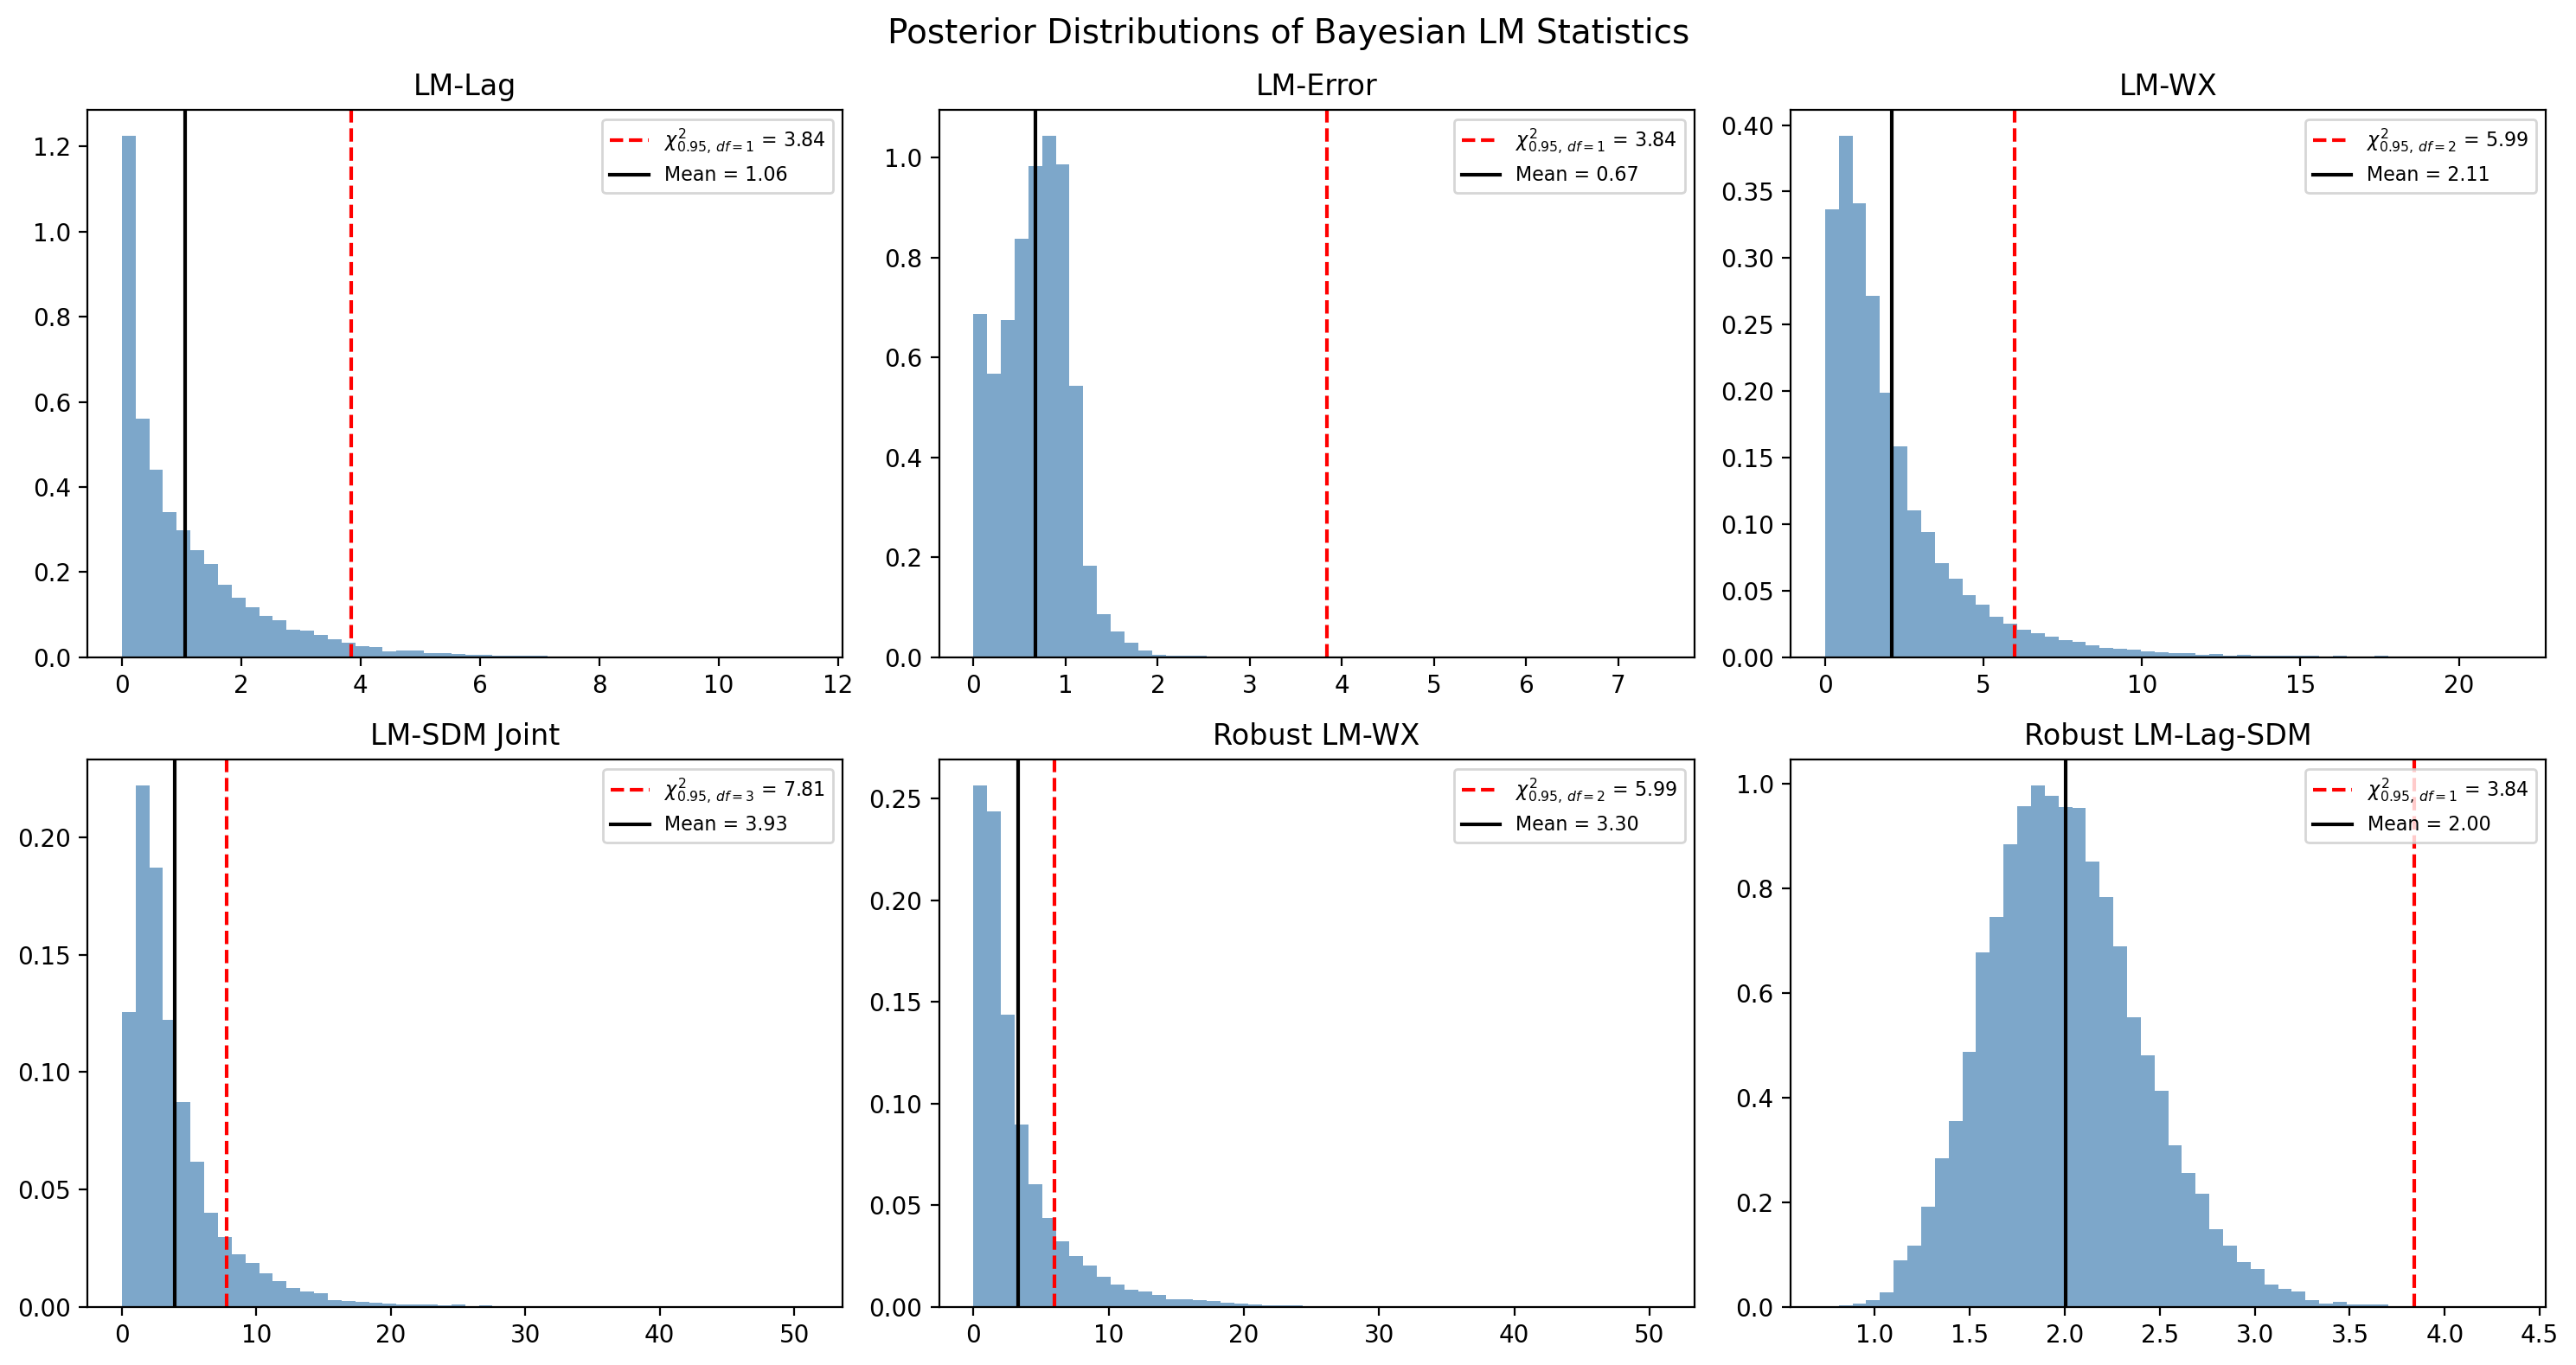

In [6]:
from scipy import stats as sp_stats

# Show six representative posterior LM distributions (a mix of non-robust and
# robust variants).  Each panel overlays the chi-squared 95% reference and the
# posterior mean.
panels = [
    ("LM-Lag", bayesian_lm_lag_test(ols_model)),
    ("LM-Error", bayesian_lm_error_test(ols_model)),
    ("LM-WX", bayesian_lm_wx_test(sar_model)),
    ("LM-SDM Joint", bayesian_lm_sdm_joint_test(ols_model)),
    ("Robust LM-WX", bayesian_robust_lm_wx_test(sar_model)),
    ("Robust LM-Lag-SDM", bayesian_robust_lm_lag_sdm_test(slx_model)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, res) in zip(axes.flat, panels):
    ax.hist(res.lm_samples, bins=50, density=True, alpha=0.7, color="steelblue")
    chi2_ref = sp_stats.chi2.ppf(0.95, res.df)
    ax.axvline(
        chi2_ref,
        color="red",
        linestyle="--",
        label=f"$\\chi^2_{{0.95,\\,df={res.df}}}$ = {chi2_ref:.2f}",
    )
    ax.axvline(res.mean, color="black", linestyle="-", label=f"Mean = {res.mean:.2f}")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Posterior Distributions of Bayesian LM Statistics", fontsize=14)
plt.tight_layout()
plt.show()

## Get a recommendation instead of a table

Every fitted spatial model exposes `spatial_diagnostics()` and `spatial_diagnostics_decision()`.
The registry on each class wires the *correct* tests for its specification:

- **OLS** → `LM-Lag`, `LM-Error`, `LM-SDM-Joint`, `LM-SLX-Error-Joint`, `Robust-LM-Lag`, `Robust-LM-Error`
- **SAR** → `LM-Error`, `LM-WX`, `Robust-LM-WX`
- **SEM** → `LM-Lag`, `LM-WX`
- **SLX** → `LM-Lag`, `LM-Error`, `Robust-LM-Lag-SDM`, `Robust-LM-Error-SDEM`
- **SDM** → `LM-Error-SDM` (uses correct $e = y - \rho Wy - X\beta - WX\gamma$ residuals)
- **SDEM** → `LM-Lag-SDEM` (uses $(I-\lambda W)$-filtered residuals)


In [8]:
# Method-based API: one call returns all wired tests as a DataFrame
ols_model.spatial_diagnostics()

,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
LM-Lag,1.063234,0.656830,1,0.302479,0.002047,4.268768
LM-Error,0.669052,0.683859,1,0.413382,0.014394,1.385391
LM-SDM-Joint,3.926935,2.786218,3,0.269463,0.425523,14.128384
LM-SLX-Error-Joint,2.113251,1.633809,3,0.549237,0.701193,6.149252
Robust-LM-Lag,0.052556,0.049121,1,0.818673,0.021080,0.102593
Robust-LM-Error,0.304723,0.284806,1,0.580937,0.122225,0.594835


OLS recommends:


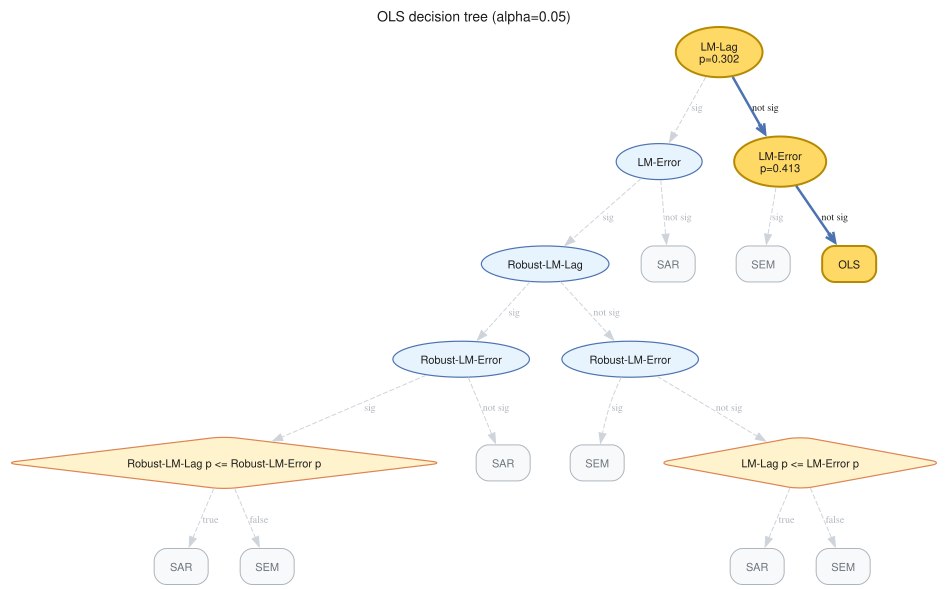

In [9]:
# The decision routine walks the appropriate tests and returns a recommendation
print("OLS recommends:")
ols_model.spatial_diagnostics_decision()

SAR recommends:


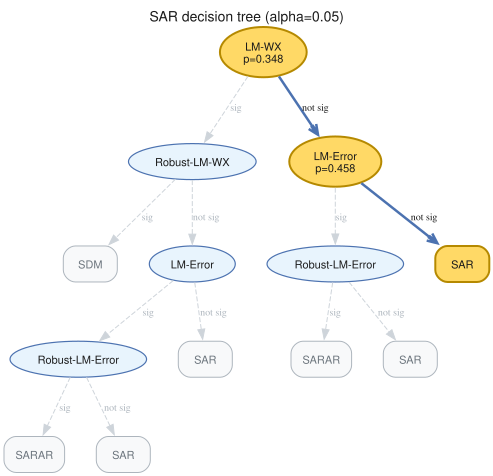

In [10]:
print("SAR recommends:")
sar_model.spatial_diagnostics_decision()

SLX recommends:


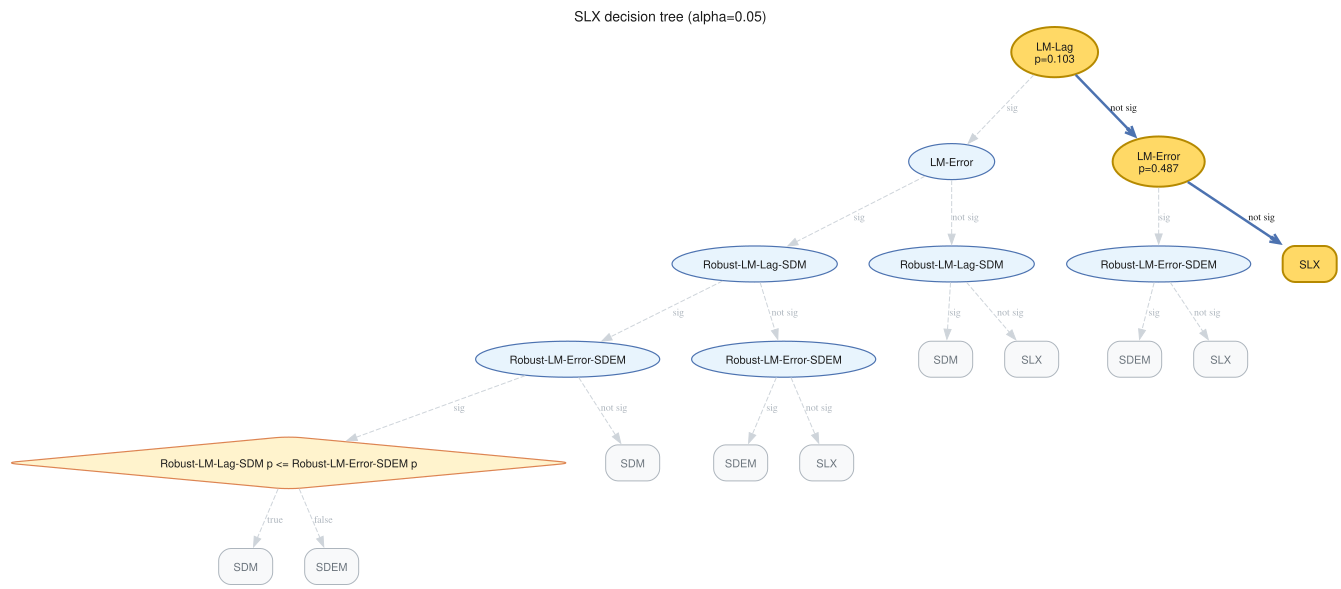

In [11]:
print("SLX recommends:")
slx_model.spatial_diagnostics_decision()

In [12]:
# SDM/SDEM-aware tests require fitted SDM / SDEM models so the residuals
# include the correct spatial filters.
sdm_model = SDM(y=y, X=X, W=g)
sdm_model.fit(draws=2000, tune=2000, chains=2, random_seed=42)

sdem_model = SDEM(y=y, X=X, W=g)
sdem_model.fit(draws=2000, tune=2000, chains=2, random_seed=42)

pd.DataFrame(
    [
        bayesian_lm_error_sdm_test(sdm_model).to_series(),
        bayesian_lm_lag_sdem_test(sdem_model).to_series(),
    ],
    index=["LM-Error-SDM", "LM-Lag-SDEM"],
)

Gibbs sampling (sdm): 2 chains for 2,000 tune and 2,000 draw iterations (2 x 4,000 = 8,000 draws total)

Output()

Gibbs sampling (sdem): 2 chains for 2,000 tune and 2,000 draw iterations (2 x 4,000 = 8,000 draws total)

Output()

,lm_samples,mean,median,credible_interval,bayes_pvalue,test_type,df,n_draws
LM-Error-SDM,"[0.32821317533390926, 0.10844000840002246, 0.3...",1.163491,0.330490,"(0.000571173339542539, 7.945960590111071)",0.280743,bayesian_lm_error_sdm,1,4000
LM-Lag-SDEM,"[5.220403887297568, 3.5843989225132122, 0.0223...",1.923766,0.835193,"(0.0016946401952680947, 9.986359293920009)",0.165442,bayesian_lm_lag_sdem,1,4000


## Run the same tests on panel data

The same Bayesian LM machinery extends to balanced spatial panels.  Tests of
the form `bayesian_panel_lm_*` and `bayesian_panel_robust_lm_*` are wired into
every panel model (`OLSPanelFE`, `SARPanelFE`, `SLXPanelFE`, …) and surfaced
through the same `spatial_diagnostics()` / `spatial_diagnostics_decision()`
methods.

Below we simulate a small balanced panel ($N = 81$, $T = 4$) from the panel
fixed-effects OLS DGP and run the full diagnostic table.

In [18]:
from neighbayes.dgp.panel_fe import simulate_panel_sar_fe
from neighbayes.dgp.utils import rook_grid_weights
from neighbayes.models import OLSPanelFE

# 9x9 rook grid (N=81), T=4 — small enough to fit quickly but large enough for
# the LM tests to behave well.
N_panel, T_panel = 81, 4
W_panel_dense, W_panel_graph = rook_grid_weights(int(np.sqrt(N_panel)))

# Simulate from a SAR-FE DGP with moderate spatial dependence so the LM-Lag
# direction is clearly significant.
panel_sim = simulate_panel_sar_fe(
    N=N_panel,
    T=T_panel,
    rho=0.4,
    beta=np.array([1.0, 2.0]),
    W=W_panel_graph,
    seed=11,
)

panel_model = OLSPanelFE(
    y=panel_sim["y"],
    X=panel_sim["X"],
    W=W_panel_graph,
    N=N_panel,
    T=T_panel,
    effects=3,  # two-way fixed effects (unit + time)
)
panel_model.fit(draws=600, tune=600, chains=2, random_seed=11, progressbar=False)

panel_model.spatial_diagnostics()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma2]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
Panel-LM-Lag,84.694264,84.656800,1,0.000000e+00,77.426851,91.951679
Panel-LM-Error,22.321703,21.940709,1,2.305858e-06,11.806254,34.658109
Panel-LM-SDM-Joint,88.138628,88.039371,2,0.000000e+00,82.867041,93.807878
Panel-LM-SLX-Error-Joint,88.422994,88.041710,2,0.000000e+00,78.285630,100.394412
Panel-Robust-LM-Lag,67.184064,66.740233,1,2.220446e-16,47.935579,91.675476
Panel-Robust-LM-Error,3.341650,3.319574,1,6.754686e-02,2.384254,4.559821


In [19]:
print(
    f"Panel decision tree (DGP = SAR-FE) recommends: {panel_model.spatial_diagnostics_decision(alpha=0.05, format='model')}"
)

Panel decision tree (DGP = SAR-FE) recommends: SARPanelFE


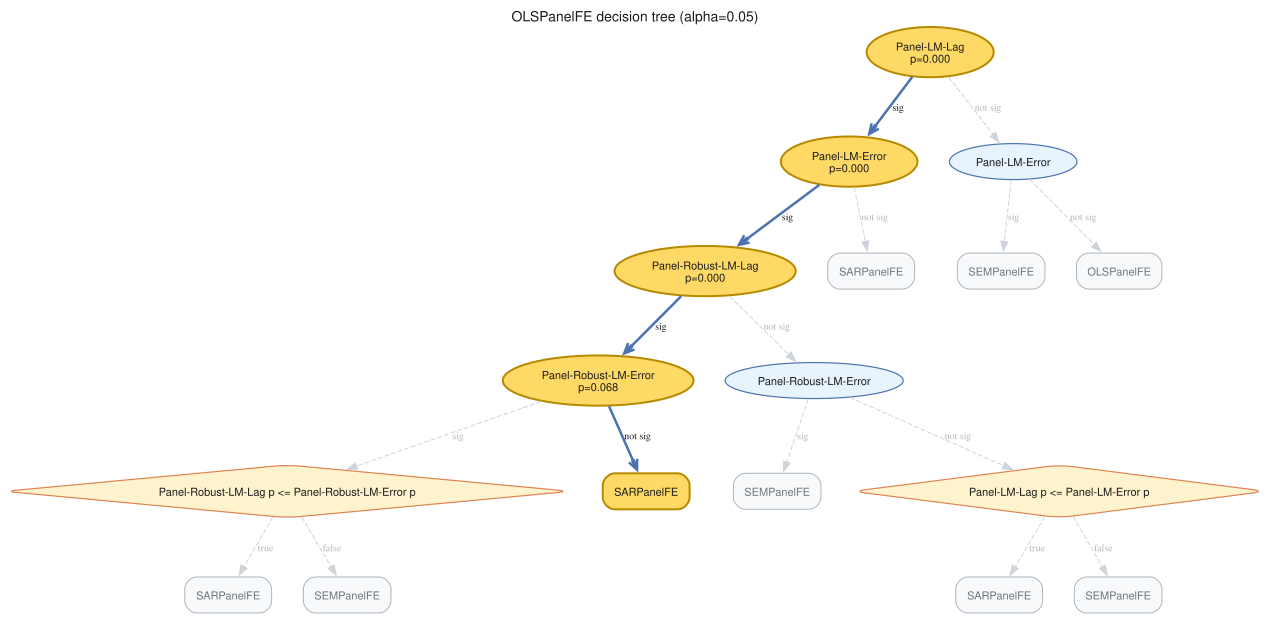

In [20]:
panel_model.spatial_diagnostics_decision(
    alpha=0.05,
)

## Run them on origin–destination flows

Origin–destination flow models in `neighbayes.models.flow` use Kronecker
weight matrices $W_d, W_o, W_w$ for destination, origin, and network
spillovers respectively.  The Bayesian LM family for flows tests each
direction separately (`bayesian_lm_flow_dest_test`,
`bayesian_lm_flow_orig_test`, `bayesian_lm_flow_network_test`,
`bayesian_lm_flow_intra_test`) plus a joint test
(`bayesian_lm_flow_joint_test`).  Robust variants are available for the
destination, origin, and network directions.

The registry on `OLSFlow` wires the full set; `SARFlow` (which already includes
all three lag terms) wires the robust variants for marginal-extension testing.

In [24]:
from neighbayes.dgp.flows import generate_flow_data
from neighbayes.models import OLSFlow, SARFlow

# Simulate a small SAR flow DGP on n=8 spatial units (N = 64 OD cells).
flow_data = generate_flow_data(
    n=8,
    rho_d=0.35,
    rho_o=0.25,
    rho_w=0.10,
    beta_d=[1.0, -0.5],
    beta_o=[0.5, 0.3],
    sigma=1.0,
    seed=42,
)

y_flow = np.log(flow_data["y_vec"])  # latent SAR scale (DGP default is lognormal)
X_flow = flow_data["X"]
G_flow = flow_data["G"]

ols_flow = OLSFlow(y_flow, X_flow, G_flow, col_names=flow_data["col_names"])
ols_flow.fit(draws=600, tune=600, chains=2, random_seed=42, progressbar=False)

ols_flow.spatial_diagnostics()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
LM-Flow-Dest,0.478937,0.218525,1,0.488904,0.001000,2.484301
LM-Flow-Orig,0.656188,0.287240,1,0.417909,0.000394,3.497080
LM-Flow-Network,0.469123,0.219796,1,0.493391,0.000477,2.263176
LM-Flow-Joint,1.635715,1.238690,3,0.651319,0.129498,5.395866
LM-Flow-Intra,1.207312,0.945413,3,0.751251,0.079454,3.749011


In [25]:
flow_data.keys()

dict_keys(['y_vec', 'y_mat', 'eta_vec', 'eta_mat', 'distribution', 'X', 'X_regional', 'X_regional_d', 'X_regional_o', 'col_names', 'design', 'W', 'G', 'gdf', 'dist', 'rho_d', 'rho_o', 'rho_w', 'sigma', 'beta_d', 'beta_o', 'gamma_dist'])

In [26]:
# Fit the SAR flow alternative; its diagnostic registry consists of the robust
# (Neyman-orthogonal) marginal-extension tests.
sar_flow = SARFlow(y_flow, X_flow, G_flow, col_names=flow_data["col_names"])
sar_flow.fit(draws=600, tune=600, chains=2, random_seed=42, progressbar=False)

sar_flow.spatial_diagnostics()

,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
Robust-LM-Flow-Dest,0.412042,0.192364,1,0.520935,0.000334,2.034098
Robust-LM-Flow-Orig,0.466157,0.226649,1,0.494761,0.000478,2.252824
Robust-LM-Flow-Network,0.551544,0.269556,1,0.457688,0.000538,2.493822
LM-Flow-Intra,1.407651,1.131638,3,0.703742,0.100356,4.479055


## See also

- [Supported Models](../models.md) — the full test inventory, null hypotheses,
  degrees of freedom, and the Neyman-orthogonal score
- [LM tests vs `spreg`](../validation/lm_tests_spreg_comparison.ipynb) —
  cross-implementation check against the classical statistics
- [LM decision-tree recovery](../validation/lm_tests_dgp_recovery.ipynb) —
  whether the tree lands on the model that generated the data
- [How to run spatial block cross-validation](spatial_cv_demo.ipynb) — the
  out-of-sample counterpart to specification testing